In [15]:

# === Core Python Utilities ===
import os, time
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
from tempfile import TemporaryDirectory

# === PyTorch Core ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# === TorchVision (for pretrained models + transforms) ===
import torchvision
from torchvision import models, transforms, datasets

# === Evaluation + Splitting ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# === Explainability (Grad-CAM) ===
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


# === Environment Setup ===
warnings.filterwarnings("ignore")

# Use Apple MPS (Metal), CUDA if available, else CPU
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"


In [16]:
DATA_DIR = "data/aptos2019-blindness-detection"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

train_images = DATA_DIR + '/train_images'
valid_images = DATA_DIR+ '/val_images'
test_images = DATA_DIR + '/test_images'
print(train_df.head())


        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0


In [17]:

#Adapted from IAI_HW3
class CropFundus:
    """Crop out the black border then tighten to a square around the retina."""
    def __call__(self, img):
        np_img = np.array(img)
        mask = np_img.sum(axis=2) > 0  # treat non-black pixels as retina signal
        coords = np.argwhere(mask)
        if coords.size == 0:
            return img  # fallback when preprocessing cannot find the disc
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        cropped = img.crop((x0, y0, x1, y1))

        w, h = cropped.size
        side = min(w, h)
        left = (w - side) // 2
        top = (h - side) // 2
        return cropped.crop((left, top, left + side, top + side))  # square crop removes wedges


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_RESIZE = 384
CROP_SIZE = 352

training_augmentations = [
    CropFundus(),
    transforms.Resize(IMG_RESIZE),
    transforms.RandomResizedCrop(CROP_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]

data_transforms = {
    'training': transforms.Compose(training_augmentations),
    'validation': transforms.Compose([
        CropFundus(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    'testing': transforms.Compose([
        CropFundus(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}


def denorm(img_tensor):
    """Undo ImageNet normalization for nicer visualization."""
    if img_tensor.ndim == 3:
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    elif img_tensor.ndim == 4:
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(1, 3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unsupported tensor shape for denorm: {img_tensor.shape}")
    return img_tensor * std + mean


In [18]:
#Adapted from https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html
class FundusDataset(Dataset):
    """Diabetic Retinopathy Fundus Image Dataset (for classification)."""
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (string): Path to the CSV file with labels.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to apply on an image.
        """
        self.labels_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        # Get the image ID and label
        img_id = str(self.labels_frame.iloc[idx, 0])  
        label = int(self.labels_frame.iloc[idx, 1])

        img_path = os.path.join(self.root_dir, f"{img_id}.png")

        if not os.path.exists(img_path):
            img_path = os.path.join(self.root_dir, f"{img_id}.jpg")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
            
        return image, label


In [19]:

#Datasets
train_ds = FundusDataset(csv_file=os.path.join(DATA_DIR, "train.csv"),
                         root_dir=os.path.join(DATA_DIR, "train_images"),
                         transform=data_transforms['training'])

val_ds = FundusDataset(csv_file=os.path.join(DATA_DIR, "valid.csv"),
                       root_dir=os.path.join(DATA_DIR, "val_images"),
                       transform=data_transforms['validation'])

test_ds = FundusDataset(csv_file=os.path.join(DATA_DIR, "test.csv"),
                        root_dir=os.path.join(DATA_DIR, "test_images"),
                        transform=data_transforms['testing'])

#Dataloaders
batch_size = 32

class_counts = train_df['diagnosis'].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weight_lookup = class_weights.to_dict()
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32, device=device)

sample_weights = train_df['diagnosis'].map(class_weight_lookup).values
sample_weights = torch.DoubleTensor(sample_weights)
train_sampler = WeightedRandomSampler(weights=sample_weights,
                                      num_samples=len(sample_weights),
                                      replacement=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_ds), 'val': len(val_ds)}


Train class counts: {0: 1434, 1: 300, 2: 808, 3: 154, 4: 234}


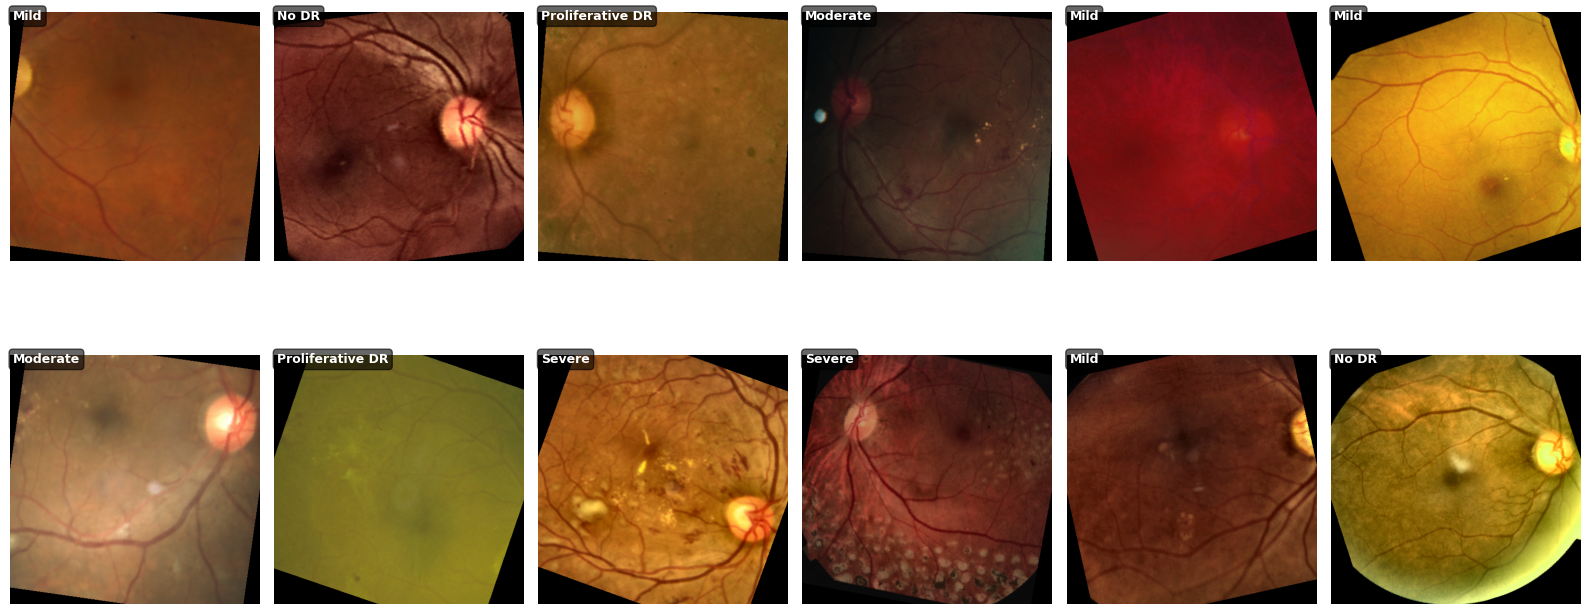

In [28]:
#Referenced from https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

def show_batch(images, labels, n=24, ncols=6):
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(16, 8))

    class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

    for i in range(n):
        ax = plt.subplot(nrows, ncols, i + 1)
        img = denorm(images[i].cpu()).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        ax.axis('off')

        label_text = class_names[int(labels[i])]
        ax.text(
            5, 15, label_text,
            color='white', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )

    plt.tight_layout()
    plt.show()


# === Example usage ===
inputs, labels = next(iter(train_loader))
show_batch(inputs, labels, n=12, ncols=6)


In [ ]:

# Configure classification head + staged fine-tuning hyperparameters
num_classes = 5
TOTAL_EPOCHS = 30
UNFREEZE_EPOCH = 5  # start fine-tuning layer4 after this epoch (1-indexed)
HEAD_LR = 3e-4
LAYER4_LR = 1e-4
WEIGHT_DECAY = 1e-4

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False  # freeze backbone by default

in_feats = model.fc.in_features
model.fc = nn.Linear(in_feats, num_classes)

for p in model.fc.parameters():
    p.requires_grad = True
for p in model.layer4.parameters():
    p.requires_grad = False

model = model.to(device)

MODEL_DIR = '/Users/smridhipatwari/Projects/retinexplain/models'
os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'resnet50_best.pt')

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(
    [
        {'params': model.fc.parameters(), 'lr': HEAD_LR},
        {'params': model.layer4.parameters(), 'lr': LAYER4_LR},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=TOTAL_EPOCHS,
    eta_min=1e-6
)


In [30]:

# Training loop logs metrics, unfreezes backbone mid-run, and saves best checkpoint
from tqdm.auto import tqdm

def get_current_lrs(optimizer):
    return [group['lr'] for group in optimizer.param_groups]

def unfreeze_layer4(model):
    for param in model.layer4.parameters():
        param.requires_grad = True

def train_model(model, criterion, optimizer, scheduler=None, num_epochs=30, unfreeze_epoch=5):
    since = time.time()
    history = {
        'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
        'lr_head': [], 'lr_layer4': []
    }

    best_acc = 0.0
    best_model_path = BEST_MODEL_PATH
    torch.save(model.state_dict(), best_model_path)
    layer4_unfrozen = False

    for epoch in range(num_epochs):
        if (not layer4_unfrozen) and (epoch + 1) >= unfreeze_epoch:
            unfreeze_layer4(model)
            layer4_unfrozen = True
            print(f'>> Unfroze layer4 at epoch {epoch + 1}')

        epoch_lrs = get_current_lrs(optimizer)
        lr_msg = ' | '.join([f'group {i}: {lr:.6f}' for i, lr in enumerate(epoch_lrs)])
        print(f"Epoch {epoch + 1}/{num_epochs}  |  LRs -> {lr_msg}")
        print('-' * 50)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss = 0.0
            running_corrects = 0

            loop = tqdm(dataloaders[phase], desc=f'{phase:>5}', leave=False)
            for inputs, labels in loop:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print(f"{phase:>5} | loss: {epoch_loss:.4f}  acc: {epoch_acc*100:5.2f}%")

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_path)

        dt = time.time() - since
        print(f"Training complete in {dt//60:.0f}m {dt%60:.0f}s")
        print(f'Best val Acc: {best_acc*100:.2f}%')

        if scheduler is not None:
            scheduler.step()

        history['lr_head'].append(epoch_lrs[0])
        history['lr_layer4'].append(epoch_lrs[1] if len(epoch_lrs) > 1 else None)
        model.load_state_dict(torch.load(best_model_path, map_location=device))

    return model, history


In [ ]:

def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def predict_all(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(1)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return np.array(y_true), np.array(y_pred)


# Train
model, history = train_model(
    model,
    criterion,
    optimizer,
    scheduler,
    num_epochs=TOTAL_EPOCHS,
    unfreeze_epoch=UNFREEZE_EPOCH
)

# Test
test_acc = evaluate(test_loader)
print(f"Test accuracy: {test_acc*100:.2f}%")

y_true, y_pred = predict_all(model, test_loader, device)
print("Macro-F1:", f1_score(y_true, y_pred, average='macro'))
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))


Epoch 1/40  |  LRs -> group 0: 0.000300 | group 1: 0.000100
--------------------------------------------------


train | loss: 0.7905  acc: 21.47%


  val | loss: 0.4173  acc:  9.29%
Training complete in 11m 52s
Best val Acc: 9.29%
Epoch 2/40  |  LRs -> group 0: 0.000300 | group 1: 0.000100
--------------------------------------------------


train | loss: 0.7138  acc: 24.03%


  val | loss: 0.3368  acc: 13.66%
Training complete in 23m 27s
Best val Acc: 13.66%
Epoch 3/40  |  LRs -> group 0: 0.000298 | group 1: 0.000099
--------------------------------------------------


...

train | loss: 0.6191  acc: 29.86%


  val | loss: 0.2593  acc: 50.27%
Training complete in 60m 2s
Best val Acc: 50.27%
Epoch 6/40  |  LRs -> group 0: 0.000289 | group 1: 0.000096
--------------------------------------------------


train | loss: 0.5890  acc: 31.16%


  val | loss: 0.2807  acc: 44.26%
Training complete in 71m 42s
Best val Acc: 50.27%
Epoch 7/40  |  LRs -> group 0: 0.000284 | group 1: 0.000095
--------------------------------------------------


train:  55%|█████▍    | 101/184 [06:28<05:15,  3.80s/it]

In [ ]:

cam_target_mode = 'ground_truth'  # or 'prediction'
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device).eval()

use_cuda = torch.cuda.is_available() and device == 'cuda'
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers, use_cuda=use_cuda,
              eigen_smooth=True, aug_smooth=True)

images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(1)

if cam_target_mode == 'prediction':
    cam_targets = [ClassifierOutputTarget(pred.item()) for pred in preds]
else:
    cam_targets = [ClassifierOutputTarget(label.item()) for label in labels]

grayscale_cams = cam(input_tensor=images, targets=cam_targets)

cam_output_dir = '/Users/smridhipatwari/Projects/retinexplain/cam_overlays'
os.makedirs(cam_output_dir, exist_ok=True)

def save_cam_overlay(path, img_tensor, cam_map):
    img = denorm(img_tensor.cpu()).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    overlay = show_cam_on_image(img.astype(np.float32), cam_map, use_rgb=True, image_weight=0.6)
    Image.fromarray(overlay).save(path)

for i in range(min(8, images.size(0))):
    rgb = denorm(images[i].cpu()).permute(1, 2, 0).numpy()
    rgb = np.clip(rgb, 0, 1)
    overlay = show_cam_on_image(rgb.astype(np.float32), grayscale_cams[i], use_rgb=True, image_weight=0.6)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f"True {labels[i].item()} | Pred {preds[i].item()}")
    axes[0].imshow(rgb)
    axes[0].set_title("Input")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    save_cam_overlay(os.path.join(cam_output_dir, f'cam_resnet50_{i}.png'), images[i], grayscale_cams[i])


In [ ]:
# 1) Loss Graph
epochs = np.arange(1, len(history['train_loss']) + 1)

plt.figure(figsize=(7,4))
plt.title("Training Summary — Loss")
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'],   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 2) Accuracy Graph
plt.figure(figsize=(7,4))
plt.title("Training Summary — Accuracy")
plt.plot(epochs, np.array(history['train_acc']) * 100, label='Train Acc')
plt.plot(epochs, np.array(history['val_acc']) * 100,   label='Validation Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

# Visualization block to monitor training dynamics
# 3) Learning rate (if you logged it each train epoch)
if len(history.get('lr_head', [])) > 0:
    epochs_lr = np.arange(1, len(history['lr_head']) + 1)
    plt.figure(figsize=(7, 3))
    plt.title("Learning Rate Schedule")
    plt.plot(epochs_lr, history['lr_head'], label='head fc')
    if any(lr is not None for lr in history.get('lr_layer4', [])):
        plt.plot(epochs_lr, history['lr_layer4'], label='layer4 block')
    plt.xlabel('Train Epoch')
    plt.ylabel('LR')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
